**Machine Translation : a Sequence to Sequence Network and Attention**
===============================================================================


在這個專案中，我們將教導一個神經網路進行翻譯「法語」到「英語」。

## **目標**

``` {.sh}
[KEY: > input, = target, < output]

> il est en train de peindre un tableau .
= he is painting a picture .
< he is painting a picture .

> pourquoi ne pas essayer ce vin delicieux ?
= why not try that delicious wine ?
< why not try that delicious wine ?

> elle n est pas poete mais romanciere .
= she is not a poet but a novelist .
< she not not a poet but a novelist .

> vous etes trop maigre .
= you re too skinny .
< you re all alone .
```
## **The Seq2Seq Model**

我們日常用來溝通的語言，例如「How are you？」、「The weather is good today！」, 可以被看待成一連串的字詞依照出現時間先後順序所做的排列，也就是時間序列(Time series)。在 NLP 領域中，有一類任務所面對的問題是輸入是一串序列(Input Sequence)：$x_1, x_2, ..., x_S$，目標的輸出也是一串序列(Target Sequence)：$y_1, y_2, ..., y_T$, 而且特別要注意的是這兩個 Sequence 的長度可以不一樣長，例如機器翻譯(Machine Translation, MT)就屬這類的任務之一，對於這樣輸入是 sequence，輸出也是 sequence 的模型我們稱為 Sequence to Sequence Model，或簡寫為 Seq2Seq Model :

<img src="https://i.imgur.com/Cu57qE2.png" width="200" height="200">

**注意 :** 這樣 Seq2Seq 的任務有兩個重點:
1. 順序性 : 資料的排序是有意義的， **_Ex_ :** $(x_1, x_2, x_3) \neq (x_2, x_3, x_1)$
2. 輸入與輸出的資料長度可以不一致 ($S \neq T$)

這樣 Seq2Seq 的模型整體架構可以再拆分為兩個部分 : **Encoder** 和 **Decoder**

* **Encoder**：其功用是把 Input Sequence 壓縮至一個固定長度的 **Context Vector** $v$，因此可以把 $v$ 認定為它夾帶了整個 Input Sequence 必要的資訊。
* **Decoder**：以 Context Vector 及 `<SOS>` Token 做為 Decoder 的起始輸入，讓 Decoder 參照 Context Vector 等於是讓 Deocder 參照到 Input Sequence 的資訊，以及 `<SOS>` 只是單純讓 Decoder 開始根據 Context vector 所夾帶的資訊給出我們期望的 Target Sequence ，隨後 Decoder 的輸出一直到 `<EOS>` Token 出現為止。

<img src="https://hackmd.io/_uploads/HkMDwqS9Jl.png" width="70%">

上面提到兩個需注意的問題 :「順序性」與「輸入與輸出的資料長度」，面對有這樣兩個特性的資料可以考慮使用 RNN 或 Transformer 模型，這邊我們考慮 RNN , RNN 可以學出資料時間先後的關聯性，並且結合 Encoder-Decoder 架構讓模型可接受輸入與輸出長度不一的資料

<img src="https://hackmd.io/_uploads/ByI5w5S51l.png" width="70%">

## **Language Model Building Process**


<img src="https://hackmd.io/_uploads/rkd4zx89ke.png" width="70%">


In [1]:
import random
import re
import unicodedata
import io
import time
import math
from tqdm.auto import tqdm # 匯入 tqdm 進度條
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim # 匯入優化器
from torch.utils.data import Dataset, DataLoader, random_split # 加入 random_split
from torch.nn.utils.rnn import pad_sequence, pad_packed_sequence

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**Data Preparation**
==================

In [2]:
!wget -O 'eng-fra.txt' 'https://github.com/HsiaoEn/nlp-transformer/releases/download/English_French_Translation_Dataset/eng-fra.txt'

--2026-08-25 15:46:46--  https://github.com/HsiaoEn/nlp-transformer/releases/download/English_French_Translation_Dataset/eng-fra.txt
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/464369906/3ecbefe8-c00c-4381-b2cb-1b146131cf5c?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-08-25T16%3A44%3A52Z&rscd=attachment%3B+filename%3Deng-fra.txt&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-08-25T15%3A44%3A31Z&ske=2026-08-25T16%3A44%3A52Z&sks=b&skv=2018-11-09&sig=iGXp%2BrfOlONH82zYR8BR7piFpbWSIh9nvktgH0QGT90%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc4NzY3MzEwNiwibmJmIjoxNzg3NjcyODA2LCJwYXRoIjoicmVsZWFz

In [3]:
with open('./eng-fra.txt', encoding='utf-8') as f:
    lines = f.readlines()  # 讀取所有行

# 印出資料筆數
print(f'Total data number {len(lines)}')

# 印出前 10 行
for i in range(10):
    print(i, lines[i].strip())

Total data number 135842
0 Go.	Va !
1 Run!	Cours !
2 Run!	Courez !
3 Wow!	Ça alors !
4 Fire!	Au feu !
5 Help!	À l'aide !
6 Jump.	Saute.
7 Stop!	Ça suffit !
8 Stop!	Stop !
9 Stop!	Arrête-toi !


In [4]:
# 隨機選擇 10 個不重複的索引
random_indices = random.sample(range(len(lines)), 10)

# 印出選中的行
for i in random_indices:
    print(i, lines[i].strip())

37716 He zipped open his bag.	Il a ouvert la fermeture-éclair de son sac.
39751 She doesn't seem happy.	Elle ne semble pas heureuse.
7820 Tom's upstairs.	Tom est en haut.
71754 There is a dog on the bridge.	Il y a un chien sur le pont.
101191 Why don't you play something for me?	Pourquoi ne jouez-vous pas quelque chose pour moi ?
85821 The wound left a scar on my arm.	La blessure me laissa une cicatrice sur le bras.
117877 I am in agreement with most of what he says.	Je suis d'accord avec la majeure partie de ce qu'il dit.
69557 I don't want Tom to see that.	Je ne veux pas que Tom voie cela.
22524 Are they all strong?	Sont-ils tous forts ?
75615 I'm sorry if I frightened you.	Je suis désolé si je vous ai effrayés.


## **Tokenization**

Tokenization 的主要目的是將一段連續的文本 (例如句子、段落或文章) 切割成一系列給模型輸入的基本單位「token」，切割方式依 tokenization 的算法而定，不同的算法對文字的切割方式也有所不同。所有的 token 會被儲存成一個詞彙表，詞彙表中所存的每一個 token 都是唯一的，並且每一個 token 會被指定一個數值 index ，這個數值 index 是幫助實現將文本資料數值化送入模型的關鍵。

**Tokenization 的重要性在於：**

1. 建立詞彙表 (Vocabulary): Tokenization 過程會產生一個詞彙表，其中包含文本中出現的所有不重複的 token。
2. 將文本轉換為數值表示: 機器學習模型無法直接處理文本數據，需要將文本轉換為數值表示。Tokenization 是實現這一轉換的第一步。
3. 處理不同語言的特性: 不同的語言有不同的分詞需求。例如，中文不像英文那樣有明顯的空格分隔單詞，因此需要更複雜的 tokenization 方法。

**Tokenization 的作法主要分為三種 :**

1. **Word-based Tokenization :** 這是最直觀的 tokenization 方法，將句子中的每個「單詞」視為一個 token。通常以空格、標點符號作為分隔符號。

  ```{.sh}
  "NLP is so interesting!" → ["NLP", "is", "so", "interesting", "!"]
  ```

2. **Character-based Tokenization :** 將句子中的每個「字符」(包括字母、數字、標點符號等) 視為一個 token。

  ```{.sh}
  "NLP is so interesting!" → ["N", "L", "P", " ", "i", "s", " ", "s", "o", " ", "i", "n", "t", "e", "r", "e", "s", "t", "i", "n", "g", "!"]
  ```
3. **Subword-based Tokenization :** 介於 word-based 和 character-based 之間，將單詞拆解成更小的「子詞」(subword) 單元。

  ```{.sh}
  "NLP is so interesting!" → ["NLP</w>", "is</w>", "so</w>", "inter", "est", "ing</w>", "!</w>"]
  ```

在做 tokenization 時，視任務需求也可自己加入一些特殊 token，如 `<SOS>`、`<EOS>` 等。

Tokenization 完成後會建立出一個詞彙表，每個 token 會對應到一個唯一的 index :

| Token | Token Index |
|:---:|:---:|
| SOS | 00 |
| EOS | 01 |
| the | 02 |
| a | 03 |
| is | 04 |
| and | 05 |
| or | 06 |
| ... | ... |

這是將文本資料數值化的第一步，接著 token index 會輸入 embedding layer 進行詞嵌入變成 embedding vector，embedding layer 是一個矩陣 (matrix)，這個矩陣的每個 row 都代表著一個 token 的 embedding vector:

| Token Index | Embedding Vector |
|:---:|:-----------------:|
| 00 | [-0.1, 0.5, 0.2] |
| 01 | [0.3, -0.2, 0.1] |
| 02 | [0.8, 0.6, -0.5] |
| 03 | [-0.4, -0.3, 0.7] |
| 04 | [0.2, 0.9, -0.1] |
| 05 | [-0.5, -0.3, 0.8] |
| 06 | [0.9, -0.2, 0.1] |
| ... | ... |

1. **輸入：** Embedding Layer 接收一個整數序列作為輸入，其中每個整數代表一個 token 在詞彙表中的 index。
2. **嵌入矩陣 (Embedding Matrix)：** Embedding Layer 內部維護一個嵌入矩陣。這個矩陣的每一個 row 對應詞彙表中一個 token 的嵌入向量。
  * 矩陣的形狀通常是 `(vocab_size, embedding_dim)`，其中 `vocab_size` 是詞彙表大小，`embedding_dim` 是嵌入向量的維度。
3. **查找 (Lookup)：** 對於輸入的每個 token index，Embedding Layer 會在嵌入矩陣中查找對應的行 (即該 token 的嵌入向量)。
4. **輸出：** Embedding Layer 輸出一個形狀為 `(batch_size, sequence_length, embedding_dim)` 的張量，其中：

  * `batch_size` 是批次大小。
  * `sequence_length` 是輸入序列的長度。
  * `embedding_dim` 是嵌入向量的維度。


為了將文本資料轉為 token ，我們建立一個類 (class) 叫 `Lang`, 其中它具有 word → index (`word2index`) 和 index → word
(`index2word`) 這兩個字典, 同時可對文本中的每一個字進行計數的字典
`word2count` 如此可以知道每個字詞在文本中的出現次數，必要時可將稀有字進行替換。


In [5]:
# --- 1. 定義特殊符號與詞彙表 ---

PAD_token = 0  # 填充符號索引
SOS_token = 1  # 起始符號索引
EOS_token = 2  # 結束符號索引
UNK_token = 3  # 未知詞符號索引

class Vocabulary:
    def __init__(self, name):
        self.name = name
        # 初始化詞彙表，包含特殊符號
        self.word2index = {"<PAD>": PAD_token, "<SOS>": SOS_token, "<EOS>": EOS_token, "<UNK>": UNK_token}
        self.word2count = {}
        self.index2word = {PAD_token: "<PAD>", SOS_token: "<SOS>", EOS_token: "<EOS>", UNK_token: "<UNK>"}
        self.n_words = 4  # 初始詞彙數量

    def add_sentence(self, sentence):
        # 將句子拆成單詞並加入詞彙表
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        # 加入單詞至詞彙表，若不存在則創建新索引
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

    def sentence_to_indices(self, sentence):
        # 將句子轉換為索引序列，並加入 SOS/EOS 符號
        indices = [self.word2index.get(word, UNK_token) for word in sentence.split(' ')]
        return [SOS_token] + indices + [EOS_token]

In [6]:
eng_sample = "Tom often cries when he's drunk."
fra_sample = "Tom pleure souvent quand il est ivre."

eng_vocab = Vocabulary('English')
print(f'word index: {eng_vocab.word2index}')
print(f'word number: {eng_vocab.n_words}')
eng_vocab.add_sentence(eng_sample)
print(f'word index after adding sentence: {eng_vocab.word2index}')
print(f'word number: {eng_vocab.n_words}')

word index: {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
word number: 4
word index after adding sentence: {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3, 'Tom': 4, 'often': 5, 'cries': 6, 'when': 7, "he's": 8, 'drunk.': 9}
word number: 10


**Question :**

上面我們的 Tokenization 方法是屬於哪一種類型 `(Word-based , Character-based, Subword-based)` 的方法?

## **Data Preprocessing**

### **Garbage in, garbage out**
**Tokenization** 是讓文本資料轉換成數值型態預備可以送進模型訓練的關鍵步驟，做好這一步可以說至少可以開始進行模型訓練。

但是 **資料的品質** 卻不是 tokenization 可以保證的，資料的品質影響到模型訓練的效能，好品質的資料才有可能帶出好的訓練成果，品質差的資料卻只能帶出差的模型。因此資料預處理是我們可以進一步去做的，以幫助模型在訓練的效果上可以提升 :

<img src='https://hackmd.io/_uploads/rJPWGU8qkl.png' width="70%">


## **Unicode 正規化 (Unicode Normalization)**

> _Humans use text. Computers speak bytes._

我們面對的法語資料其中會出現夾帶變音符號 (diacritic) 的文字，如 「**`é`**」，為了對資料進行簡化，一個考慮的方向是可以試著移除這些變音符，讓最後資料中使用的文字都以英文字母呈現 :
```{.sh}
café → cafe
```

### **什麼是 Unicode ?**

Unicode 是一個國際標準，旨在為世界上所有的書寫系統（包括各種語言的字母、音節文字、漢字、符號等等）提供一個統一的編碼方式。每個字元都被分配一個唯一的「碼點 (code point)」。例如：

- 'A' 的碼點是 U+0041
- '中' 的碼點是 U+4E2D
- 'é' 的碼點是 U+00E9
- '😀' 的碼點是 U+1F600


### **Unicode 字元表示方式**

Unicode 的一個重要特性是，**有些字元可以用多種方式表示**。這主要是因為：

- **預組合字元 (Precomposed Characters) :** 某些字元有單一的碼點，例如 "é" (帶有尖音符的 e) 可以直接用 U+00E9 表示。
- **組合序列 (Combining Sequences) :** 同樣的字元 "é" 也可以用一個基本字元 "e" (U+0065) 加上一個組合用尖音符 "́" (U+0301) 來表示。

這兩種表示方式在視覺上是相同的，但在電腦內部卻是不同的碼點序列。

```{.sh}
s1 = 'é' # Precomposed Character U+00E9
s2 = 'e\u0301' # Combining Sequence U+0065 + U+0301

print(s1) # é
print(s2) # é
print(s1 == s2) # False
```

如此有多個碼點表現相同的文字視覺的特性會引發一些問題 :

- **比較問題 :** 如果你直接比較兩個字串，即使它們看起來一樣，但如果一個使用預組合字元，另一個使用組合序列，比較結果可能會是「不相等」。
- **搜尋問題 :** 搜尋引擎或文字編輯器可能無法正確找到所有包含 "é" 的字串，如果它們的內部表示方式不同。
- **排序問題 :** 排序演算法可能會因為不同的表示方式而產生不一致的結果。


### **Unicode 正規化的形式 (Normalization Forms)**

Unicode 定義了四種主要的正規化形式(**NFD、NFC、NFKD、NFKC**)：

- **NFD (Normalization Form D - Canonical Decomposition) :** 將字元分解為基本字元和組合記號。
```{.sh}
é → e + ́ (U+0065 + U+0301)
```
- **NFC (Normalization Form C - Canonical Composition) :** 盡可能將分解後的字元重新組合成預組合字元。它會把 "e" + "́" 組合成 "é"。
```{.sh}
e + ́ → é (U+00E9)
```
**NFK** 系列(NFKD 和 NFKC)的核心目標是「消除字元間的『相容性』差異」:

- 「相容性 (Compatibility)」差異:
  - 兩個（或多個）字元，雖然在 Unicode 中有不同的碼點 (code point)，但它們本質上代表相同或相近的「基礎字元」。
  - 這些字元的存在，通常是為了相容舊的字元集、或為了特定的排版/樣式需求。

  - **例子：**

    - 1 (U+0031)：標準的數字 1
    - ¹ (U+00B9)：上標數字 1
    - ① (U+2460)：帶圈數字 1

      在 NFK 規範的眼中，¹ 和 ① 都只是 1 的「相容性變體」。
- **NFKD (Normalization Form KD - Compatibility Decomposition) :** 將字串拆解成最原始、最基礎的組成部分，去除所有樣式和組合。

  1.   **相容性分解 (K)：** 將所有「相容性字元」拆解回其基礎字元。
  2.   **標準分解 (D)：** 將「預組合字元」（如 é）拆解成「基礎字元 + 附加符號」（如 e + ´）。

  例如，它會將 "é¹" (帶重音的 e 和上標 1) 分解成 "e´1"(字元 e + 重音符 ´ + 數字 1):
  - é 被 (D) 分解成 e´
  - ¹ 被 (K) 分解成 1
```{.sh}
é¹ → e + ´ + 1 (NFKD)
```
- **NFKC (Normalization Form KC - Compatibility Composition) :**

  1. **先執行 NFKD:** 將字串徹底分解成最基礎的元件 (去除所有相容性樣式)
  2. **執行 NFC:** 重新組合那些可以被「標準組合 (Composition)」的字元，讓字串變回「最簡潔、最標準」的預組合形式。
```{.sh}
é¹ → e + ´ + 1 (NFKD) → é + 1 (NFC)
```

NFK 系列是一種「有損 (lossy)」的轉換，因為會遺失「上標」、「帶圈」或「連字」這些原始的樣式資訊。

In [7]:
for c in unicodedata.normalize('NFD', 'é¹'):
  print(c)

e
́
¹


### **Unicode 一般字元類別 (General Category)**

Unicode 將每個字元都分配到一個「一般類別 (General Category)」。這是一種將字元按其主要用途和特性進行分類的方式。例如：

- 字母 (Letters)
- 標點符號 (Punctuation)
- 數字 (Numbers)
- 符號 (Symbols)
- 分隔符號 (Separators)
- 控制字元 (Control characters)

每個一般類別都有一個雙字母的縮寫代碼 :

|代碼|描述 (英文)|描述(中文)|範例|
|---|-----------|---------|----|
|Lu|Letter, Uppercase|大寫字母|A, B, C, 漢, あ      |
|Ll|Letter, Lowercase|小寫字母| a, b, c, っ         |
|Lt|Letter, Titlecase|詞首大寫字母|(通常用於組合字元)|
|Lm|Letter, Modifier |修飾字母|(用於表示音調等)      |
|Lo|Letter, Other    |其他字母|中, 日, 韓文等        |
|Mn|Mark, Nonspacing |非間距標記| ́, ̈, ̀  (組合用變音符號)|
|Nd|Number, Decimal Digit|十進位數字|0, 1, 2, 3, 4, 5, 6, 7, 8, 9|
|Nl|Number, Letter|字母數字|Ⅰ, Ⅱ, Ⅲ (羅馬數字)|
|No|Number, Other| 其他數字| ½, ¾             |
|...|...         |...     |...                |

**'Mn' :** Mark, Nonspacing 主要包含 組合用變音符號 (Combining Diacritical Marks)。Mn 字符通常 _不應該_ 單獨顯示。它們的目的是修改前面的基本字符。如果試圖單獨顯示一個 Mn 字符，它可能會顯示為一個小方塊、問號、一個空白，或者與前一個字符重疊（但如果前一個字符不是基本字符，重疊的效果可能不正確）。Mn 字符必須與一個基本字符結合才能正確顯示。


In [8]:
# --- 2. 文字正規化 ---
def unicode_to_ascii(s):
    # 將 Unicode 轉換為 Ascii
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalize_string(s):
    # 正規化字串：轉小寫、去除非字母數字、處理標點符號
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s) # 標點符號前後加空格
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s) # 非字母/標點替換為空格
    s = re.sub(r'\s+', ' ', s).strip() # 合併多餘空格
    return s

In [9]:
unicode_to_ascii("À l'aide !")

"A l'aide\u202f!"

In [10]:
normalize_string("À l'aide !")

'a l aide !'

為了讀取資料，我們將檔案按行拆分，然後再將每一行拆分成句對 :

```{.sh}
[[Source_1, Target_1], [Source_2, Target_2], [Source_3, Target_3], ...]
```


In [11]:
# --- 3. 資料讀取與準備 ---
def read_data(lines):
    """從讀取的行列表中解析語言對"""
    pairs = []
    for line in lines:
        parts = line.strip().split('\t')
        if len(parts) == 2:
            # parts[0] 是英文 (target), parts[1] 是法文 (source)
            eng_normalized = normalize_string(parts[0])
            fra_normalized = normalize_string(parts[1])
            if eng_normalized and fra_normalized:
                pairs.append((fra_normalized, eng_normalized)) # (法文, 英文)
        # else:
            # print(f"Skipping invalid line: {line.strip()}") # 可選擇打印格式不符的行
    return pairs

# 讀取檔案 (請確保 eng-fra.txt 在當前路徑)
with open('./eng-fra.txt', encoding='utf-8') as f:
    lines = f.readlines()

print(f'Total data lines read: {len(lines)}')

pairs = read_data(lines)
print("Normalized pairs count:", len(pairs))
print("Sample pairs:")
for i in range(min(10, len(pairs))): # 印出前 10 個樣本
    print(pairs[i])

Total data lines read: 135842
Normalized pairs count: 135842
Sample pairs:
('va !', 'go .')
('cours !', 'run !')
('courez !', 'run !')
('ca alors !', 'wow !')
('au feu !', 'fire !')
('a l aide !', 'help !')
('saute .', 'jump .')
('ca suffit !', 'stop !')
('stop !', 'stop !')
('arrete toi !', 'stop !')


In [12]:
# --- 4. 建立詞彙表實例 ---
french_vocab = Vocabulary("french")
english_vocab = Vocabulary("english")

for fr_sent, en_sent in pairs:
    french_vocab.add_sentence(fr_sent)
    english_vocab.add_sentence(en_sent)

print(f"French vocabulary size: {french_vocab.n_words}")
print(f"English vocabulary size: {english_vocab.n_words}")
print("French word2index sample:", list(french_vocab.word2index.items())[:10])
print("English word2index sample:", list(english_vocab.word2index.items())[:10])

French vocabulary size: 21335
English vocabulary size: 13044
French word2index sample: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('va', 4), ('!', 5), ('cours', 6), ('courez', 7), ('ca', 8), ('alors', 9)]
English word2index sample: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('go', 4), ('.', 5), ('run', 6), ('!', 7), ('wow', 8), ('fire', 9)]


`torch.utils.data.Dataset` 是一個代表資料集的抽象類別 (abstract class)。所自訂的資料集應該繼承 (inherit) `Dataset` 並覆寫 (override) 以下方法：

- `__len__`：如此一來 `len(dataset)` 就能回傳資料集的大小。
- `__getitem__`：用以支援索引 (indexing)，使得 `dataset[i]` 可以被用來取得第 i 個樣本 (sample)。

In [13]:
# --- 5. PyTorch Dataset ---
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_sentence, trg_sentence = self.pairs[idx]
        src_indices = self.src_vocab.sentence_to_indices(src_sentence)
        trg_indices = self.trg_vocab.sentence_to_indices(trg_sentence)
        return src_indices, trg_indices

# 創建 Dataset 實例
dataset = TranslationDataset(pairs, french_vocab, english_vocab)

print("\nDataset samples (indices):")
for _ in range(min(5, len(dataset))):
    random_index = random.randint(0, len(dataset) - 1)
    sample_fr, sample_en = dataset[random_index]
    print("French:", sample_fr)
    print("English:", sample_en)
    print("French (words):", ' '.join([french_vocab.index2word[i] for i in sample_fr]))
    print("English (words):", ' '.join([english_vocab.index2word[i] for i in sample_en]))
    print("-" * 20)


Dataset samples (indices):
French: [1, 116, 6708, 65, 667, 730, 12, 190, 2237, 65, 504, 71, 131, 4700, 16, 2]
English: [1, 525, 5971, 3829, 232, 1161, 3209, 202, 525, 3253, 5, 2]
French (words): <SOS> le concert en plein air a ete annule en raison de la tempete . <EOS>
English (words): <SOS> the outdoor concert was canceled due to the storm . <EOS>
--------------------
French: [1, 1965, 1966, 23, 264, 378, 761, 545, 23, 140, 53, 75, 658, 62, 349, 470, 16, 2]
English: [1, 14, 197, 397, 1035, 2814, 14, 93, 367, 148, 964, 202, 244, 5, 2]
French (words): <SOS> aujourd hui je me sens mieux mais je ne suis pas assez bien pour travailler . <EOS>
English (words): <SOS> i feel better today but i am not well enough to work . <EOS>
--------------------
French: [1, 215, 129, 382, 133, 3662, 71, 1616, 35, 14118, 176, 65, 725, 116, 3662, 7376, 16, 2]
English: [1, 1727, 83, 199, 202, 88, 519, 8178, 174, 229, 494, 88, 374, 8178, 525, 3113, 494, 5, 2]
French (words): <SOS> si vous oubliez un jour de p

`collate_fn` 是一個傳遞給 `DataLoader` 的函式，它扮演著「批次組裝工」的角色。

- **預設情況 (`default_collate`)：** 適用於所有樣本形狀都一致的標準情況。它會自動將 NumPy/Python 數值轉為 Tensor，並在第 0 維度上堆疊 (stack) 起來。

- **自訂情況 (Custom `collate_fn`)：** 當您的樣本長度不一（如文字序列、時間序列）或具有複雜的資料結構時，您必須自己定義 `collate_fn` 來正確地將它們「填充」並「堆疊」成一個合法的批次。


`collate_fn` 的核心功用：**彙整**

`collate_fn` 的主要工作是：將一個「樣本列表」轉換成一個 **「批次張量」** 。

當 `DataLoader` 啟用自動批次處理 (automatic batching) 時（預設情況），它會：

1. 從您的 `Dataset` 中呼叫 `__getitem__` 數次（次數等於 `batch_size`）。
2. 將這些取回來的樣本（例如：`sample1`, `sample2`, ...）放進一個 Python 列表中：[sample1, sample2, ...].
3. 將這個列表傳遞給 `collate_fn` 函式。
4. `collate_fn` 負責將這個列表「彙整」成一個或多個批次化的張量。

[working-with-collate-fn](https://docs.pytorch.org/docs/stable/data.html#working-with-collate-fn)

[default_collate](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.default_collate)

In [14]:
# --- 6. Collate Function (用於 DataLoader) ---
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
    """將批次資料(Python list)進行填充"""
    src_batch, trg_batch = zip(*batch)

    # 將 Python list 轉換為 Tensors
    src_tensors = [torch.tensor(s, dtype=torch.long) for s in src_batch]
    trg_tensors = [torch.tensor(t, dtype=torch.long) for t in trg_batch]

    # 執行 padding
    src_padded = pad_sequence(src_tensors, batch_first=True, padding_value=PAD_token)
    trg_padded = pad_sequence(trg_tensors, batch_first=True, padding_value=PAD_token)

    # 返回填充後的 Tensor
    return src_padded, trg_padded

example_dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

BATCH_SIZE = 4

# 顯示一個批次的資料
print(f"\nDataLoader 範例 (Batch Size = {BATCH_SIZE}):")
for i, (french_batch, english_batch) in enumerate(example_dataloader):
    print(f"--- Batch {i+1} ---")
    print("法文批次 Tensor 形狀:", french_batch.shape) # (batch_size, max_french_len_in_batch)
    print("英文批次 Tensor 形狀:", english_batch.shape) # (batch_size, max_english_len_in_batch)
    print("\n法文批次 (填充後):")
    print(french_batch)
    print("\n英文批次 (填充後):")
    print(english_batch)
    # 只顯示第一個批次作為範例
    break


DataLoader 範例 (Batch Size = 4):
--- Batch 1 ---
法文批次 Tensor 形狀: torch.Size([4, 12])
英文批次 Tensor 形狀: torch.Size([4, 11])

法文批次 (填充後):
tensor([[   1,   89, 2476,  893,   71,  129, 3250,   16,    2,    0,    0,    0],
        [   1,  129,  632, 6515,   16,    2,    0,    0,    0,    0,    0,    0],
        [   1,   73, 1030, 6633, 5061,  276,   16,    2,    0,    0,    0,    0],
        [   1,   84,   85,  589,   71,  352,  431,   84, 1893,  122,   16,    2]])

英文批次 (填充後):
tensor([[   1,   43,  233,   45,  747,  202,   15,   83,  306,    5,    2],
        [   1,   83,  311, 3686,    5,    2,    0,    0,    0,    0,    0],
        [   1,   62,  363, 3928,  327,    5,    2,    0,    0,    0,    0],
        [   1,   41, 5709,  173,  202,  335,    5,    2,    0,    0,    0]])


**The Seq2Seq Model**
=================
回想上面介紹的 seq2seq model，我們模型 input 和 output 的方式就會如下呈現:

<img src="https://hackmd.io/_uploads/SkgZveemskl.png" width="70%">

**注意:** 在 Decoder 的地方，前一個時間點的輸出會成為下一個時間點的輸入，直到 `<EOS>` 出現為止。


## **The Encoder**

Seq2seq network 的 encoder 使用 RNN 架構。在過程中，模型會將 input sentence 的每個「字」當作輸入產生 output vector 與 hidden state，這個 hidden state 會在下一個字輸入進 RNN 時，同時也作為 RNN state 的輸入。

RNN 有兩種特別的型式，分別為 `LSTM` 與 `GRU`，這邊我們使用 `GRU`:

<img src="https://hackmd.io/_uploads/rJ-CQ-s9kx.png" width="50%">


In [15]:
# --- 7. Encoder 編碼器 (GRU) ---
class EncoderRNN(nn.Module):
    def __init__(self, input_vocab_size, embedding_dim, hidden_size, num_layers=1, dropout=0.1, bidirectional=False):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(input_vocab_size, embedding_dim, padding_idx=PAD_token)
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers=num_layers, batch_first=True, bidirectional=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input):
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(embedded)
        return output, hidden

## **The Decoder**

Decoder 是另外一部分的 RNN 它的輸入包含 encoder 的 output vector(s) 並且以序列的形式輸出翻譯過後的單字。

### **Simple Decoder**

在簡單版的 seq2seq 架構中，我們只會讓 decoder 使用 encoder 最後產出的 output。
這個最後產出的 output 稱為 *context vector*，它將 input sequence 的資訊編碼(encode)成一個向量。

在每個解碼(decode)的步驟中，decoder 會被給定一個 input token 和前一個時間點產生的 hidden state。在最一開始 decoder 所接受的 input 為 `<SOS>` token，代表的意義為 start-of string 並且 decoder 接受的第一個 hidden state 為 context vector(由 encoder 最後產生的 hidden state)。

我們希望模型在推論階段 decoder 可以將上一個時間點的 output 作為下一個時間點的 input 用以讓 decoder 知道在下一個時間點需要生成什麼字，但是在模型訓練階段時，一開始 deocder 給的 output 往往與真正的 target 相差甚遠，如此會讓訓模難以收斂。

為了幫助 decoder 進行訓練，可以使用 **_teach forcing_** 的技巧，此方法在模型訓練時 decoder 在每一個時間點的 input，不論上一個時間點的 output 為何，皆提供真正的 target，讓 decoder 可以因為接收正確的 target 而矯正它的 output。

<img src="https://hackmd.io/_uploads/r1Gwezdjye.png" width="70%">


In [16]:
# --- 8. Decoder 解碼器 (GRU, 無 Attention) ---
class DecoderRNN(nn.Module):
    def __init__(self, output_vocab_size, embedding_dim, hidden_size, num_layers=1, dropout=0.1):
        super().__init__()
        self.decoder_hidden_size = hidden_size
        self.num_layers = num_layers
        self.output_vocab_size = output_vocab_size

        self.embedding = nn.Embedding(output_vocab_size, embedding_dim, padding_idx=PAD_token) # 指定 padding_idx
        self.gru = nn.GRU(embedding_dim, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_size, output_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, decoder_input, hidden_state, encoder_outputs=None):
        """Decoder 單步前向傳播"""
        # decoder_input: (batch, 1)
        embedded = self.dropout(self.embedding(decoder_input)) # (batch, 1, embed_dim)
        output, hidden_state = self.gru(embedded, hidden_state) # output: (batch, 1, decoder_hidden_size), hidden: (num_layers, batch, hidden_size)
        output = self.fc_out(output) # (batch, 1, output_vocab_size)
        return output, hidden_state, None

In [17]:
# --- 9. Seq2Seq 模型 ---
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5, return_attention=False):
        # 1. 準備維度
        batch_size = trg.shape[0]
        trg_len = trg.shape[1]

        # 取得 Decoder 的詞彙表大小 (用於建立儲存 logits 的 tensor)
        trg_vocab_size = self.decoder.output_vocab_size

        # 2. 建立一個 tensor 來儲存所有時間步的 Decoder 輸出
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)

        # 需要時，建立 attention 儲存 tensor
        if return_attention:
          all_attentions = torch.zeros(batch_size, trg_len, src_len).to(self.device)
        else:
          all_attensions = None

        # 3. Encoder 運行 (一次性)
        #    encoder_outputs: (batch_size, src_len, encoder_hidden_size)
        #    hidden: (num_layers, batch_size, decoder_hidden_size)
        encoder_outputs, hidden = self.encoder(src)

        # 4. 準備 Decoder 的第一個輸入 (永遠是 <SOS> token)
        #    trg[:, 0] 是 <SOS> token
        decoder_input = trg[:, 0].unsqueeze(1) # (batch_size, 1)

        # 5. Decoder 迴圈 (一步一步解碼)
        #    從 t=1 開始，因為 t=0 是 <SOS>
        for t in range(1, trg_len):

            # 執行 Decoder 的單步 forward
            # decoder_output: (batch_size, 1, output_vocab_size)
            # hidden: (num_layers, batch_size, decoder_hidden_size)
            decoder_output, hidden, attn_weights = self.decoder(
                decoder_input,
                hidden,
                encoder_outputs
            )

            # 儲存這個時間步的預測 (logits)
            # 我們需要 squeeze(1) 移除中間的 '1' 維度
            outputs[:, t] = decoder_output.squeeze(1)

            # 儲存 attention 權重
            if return_attention:
              # attn_weights shape 是 (batch, 1, src_len)
              all_attentions[:, t] = attn_weights.squeeze(1)

            # 決定是否使用 "教師強制"
            use_teacher_force = random.random() < teacher_forcing_ratio

            if use_teacher_force:
                # 下一步的輸入是 "標準答案"
                decoder_input = trg[:, t].unsqueeze(1) # (batch_size, 1)
            else:
                # 下一步的輸入是 "模型自己的預測"
                # (從 logits 中取出機率最高的 token)
                # top1 shape: (batch_size, 1)
                top1 = decoder_output.argmax(2)
                decoder_input = top1

        if return_attention:
          return outputs, all_attentions[:, 1:] # 只返回 t=1 之後的有效 attention (去掉 t=0 的 0)
        else:
          return outputs

In [18]:
# 模型參數設定
INPUT_VOCAB_SIZE = french_vocab.n_words # 法文詞彙表大小
OUTPUT_VOCAB_SIZE = english_vocab.n_words # 英文詞彙表大小
EMBEDDING_DIM = 256
ENCODER_HIDDEN_SIZE = 512
DECODER_HIDDEN_SIZE = 512
NUM_LAYERS = 2 # 使用 2 層 GRU
DROPOUT = 0.3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 創建 Encoder 和 Decoder 實例
encoder = EncoderRNN(INPUT_VOCAB_SIZE, EMBEDDING_DIM, ENCODER_HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
decoder = DecoderRNN(OUTPUT_VOCAB_SIZE, EMBEDDING_DIM, DECODER_HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)

# 創建 Seq2Seq 模型實例
seq2seq_model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

# 印出模型結構
print("Seq2Seq Model without Attention:")
print(seq2seq_model)

Seq2Seq Model without Attention:
Seq2Seq(
  (encoder): EncoderRNN(
    (embedding): Embedding(21335, 256, padding_idx=0)
    (gru): GRU(256, 512, num_layers=2, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): DecoderRNN(
    (embedding): Embedding(13044, 256, padding_idx=0)
    (gru): GRU(256, 512, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=13044, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)


**Model Training**
========

In [19]:
# --- 10. 資料分割 ---
def split_dataset(dataset, train_ratio=0.9):
    """將資料集分割為訓練集和驗證集"""
    train_size = int(train_ratio * len(dataset))
    val_size = len(dataset) - train_size
    print(f"Splitting dataset: {len(dataset)} samples -> Train: {train_size}, Validation: {val_size}")
    return random_split(dataset, [train_size, val_size])

TRAIN_RATIO = 0.9    # 訓練集比例
train_dataset, val_dataset = split_dataset(dataset, train_ratio=TRAIN_RATIO)

Splitting dataset: 135842 samples -> Train: 122257, Validation: 13585


## **Define Training Process**

為了訓練，我們透過 encoder 運行輸入句子，並追蹤每個輸出和最新的隱藏狀態。然後，decoder 將 `<SOS>` token 作為其第一個輸入，並將 encoder 的最後一個隱藏狀態作為其第一個隱藏狀態。

**Teacher forcing** 的概念是使用真實 target 輸出作為下一個輸入，而不是使用 decoder 的 prediction 作為下一個輸入。使用 teacher forcing 會導致其收斂得更快，但是當訓練好的網路被用作推論時，它可能會表現出不穩定性。

出現這樣不穩定性的原因是由於模型在做推論時 decoder 接收到的輸入為上一個時間點模型的輸出，如此 decoder 不會像訓練時有 target 當作輸入，而當 decoder 接收到的輸入與訓練時資料不一致的輸入時就容易造成 decoder 的效能下降，這種現象被稱為 **Exposure Bias**。

Teacher Forcing 是一種有效的訓練技巧，特別是在訓練初期，可以加速模型收斂並提高訓練穩定性。然而，Exposure Bias 的問題是其主要缺點，需要通過一些策略來緩解，如: Scheduled Sampling。

In [20]:
# --- 11. 訓練函數 (單輪) ---
def train_epoch(model, dataloader, optimizer, criterion, device, teacher_forcing_ratio=0.5, clip=1.0):
    model.train() # Dropout 層啟動 / Batch Normalization 層採當前批次統計數據
    epoch_loss = 0

    for src_batch, trg_batch in tqdm(dataloader, desc="Training", leave=False):
        src_batch, trg_batch = src_batch.to(device), trg_batch.to(device)

        # 1. 歸零梯度
        optimizer.zero_grad()

        # 2. 向前傳播
        outputs = model(src_batch, trg_batch, teacher_forcing_ratio) # (batch_size, max_trg_len, trg_vocab_size)

        # 3. 計算 loss
        output_for_loss = outputs[:, 1:].reshape(-1, outputs.size(-1)) # 使用 outputs
        trg_for_loss = trg_batch[:, 1:].reshape(-1)
        loss = criterion(output_for_loss, trg_for_loss)

        # 4. 反向傳播
        loss.backward()

        # 5. 梯度裁切 (防止梯度爆炸)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)

        # 6. 更新參數 (梯度下降)
        optimizer.step()

        epoch_loss += loss.item() # loss 返回的是 tensor，用 item 將值取出

    return epoch_loss / len(dataloader)

In [21]:
# --- 12. 驗證函數 (單輪) ---
def evaluate_epoch(model, dataloader, criterion, device):
    model.eval() # 關閉 Dropout 層 / Batch Normalization 層採用全局統計數據
    epoch_loss = 0

    with torch.no_grad(): # 關閉梯度計算 (autograd)
        for src_batch, trg_batch in tqdm(dataloader, desc="Evaluating", leave=False):

            src_batch, trg_batch = src_batch.to(device), trg_batch.to(device)

            outputs = model(src_batch, trg_batch, teacher_forcing_ratio=0.0)

            output_for_loss = outputs[:, 1:].reshape(-1, outputs.size(-1))
            trg_for_loss = trg_batch[:, 1:].reshape(-1)

            loss = criterion(output_for_loss, trg_for_loss)

            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

In [22]:
# --- 13. 主訓練迴圈 ---
def train_model(model, train_dataset, val_dataset, collate_fn, device,
                n_epochs=10, batch_size=64, lr=0.001, teacher_forcing_ratio=0.5,
                clip=1.0, save_path='best_model.pt',
                early_stopping_patience=3):

    # 創建 DataLoader
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    print(f"\n--- Starting Training---")
    print(f"Total Epochs: {n_epochs}")
    print(f"Batch Size: {batch_size}")
    print(f"Device: {device}")
    print(f"Saving best model to: {save_path}")
    print(f"Early Stopping Patience: {early_stopping_patience}")
    print("-" * 40)

    # 定義損失函數 (忽略 <PAD>)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_token)

    # 定義優化器
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # --- Early Stopping 相關變數初始化 ---
    best_val_loss = float('inf') # 儲存最好的 val loss
    epochs_no_improve = 0        # 記錄「連續」沒有改善的 epoch 次數
    early_stop = False

    # 用於記錄損失歷史
    train_loss_history = []
    val_loss_history = []

    # 訓練迴圈
    for epoch in range(n_epochs):
        start_time = time.time()

        # 訓練
        train_loss = train_epoch(model, train_dataloader, optimizer, criterion, device, teacher_forcing_ratio, clip)

        # 驗證
        val_loss = evaluate_epoch(model, val_dataloader, criterion, device)

        # 記錄當前 epoch 的損失
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        print(f'\nEpoch {epoch+1}/{n_epochs}')
        print(f'\tTrain Loss: {train_loss:.4f}')
        print(f'\tVal. Loss: {val_loss:.4f}')

        # --- Early Stopping 檢查 ---
        if val_loss < best_val_loss:
            # 驗證損失有改善
            best_val_loss = val_loss
            epochs_no_improve = 0  # 重置「耐心」計數器

            # 保存模型 (只有在改善時才保存)
            torch.save(model.state_dict(), save_path)
            print(f'\tValidation loss improved ({best_val_loss:.4f}). Saving model to {save_path}')
        else:
            # 驗證損失沒有改善
            epochs_no_improve += 1 # 增加「耐心」計數器
            print(f'\tValidation loss did not improve. Patience: {epochs_no_improve}/{early_stopping_patience}')

        # 檢查是否觸發 Early Stopping (耐心耗盡)
        if epochs_no_improve >= early_stopping_patience:
            print(f'\nEarly stopping triggered after epoch {epoch + 1}!')
            early_stop = True
            break # 跳出訓練迴圈

    if early_stop:
        print(f"--- Training finished early after {len(train_loss_history)} epochs ---")
    else:
        print("--- Training Finished (Completed all epochs) ---")

    print(f"Best Validation Loss achieved: {best_val_loss:.4f}")

    # 返回損失歷史列表
    return train_loss_history, val_loss_history

### **Training**

In [23]:
N_EPOCHS = 20           # 訓練 epochs 數 (可自行調整)
BATCH_SIZE = 64         # 批次大小 (可自行調整)
LEARNING_RATE = 0.001   # 學習率
CLIP = 1.0              # 梯度裁切
TEACHER_FORCING_RATIO = 0.5 # 教師強制比例
EARLY_STOP_PATIENCE = 5   # 提早停止的耐心值
SAVE_PATH = 'best_seq2seq_model_no_attn.pt' # 模型儲存路徑

train_history, val_history = train_model(
    model=seq2seq_model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    collate_fn=collate_fn,
    device=DEVICE,
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    teacher_forcing_ratio=TEACHER_FORCING_RATIO,
    clip=CLIP,
    save_path=SAVE_PATH,
    early_stopping_patience=EARLY_STOP_PATIENCE
)

print("\n--- Training Finished ---")
print(f"Best model saved to: {SAVE_PATH}")


--- Starting Training---
Total Epochs: 20
Batch Size: 64
Device: cuda
Saving best model to: best_seq2seq_model_no_attn.pt
Early Stopping Patience: 5
----------------------------------------


Training:   0%|          | 0/1911 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/213 [00:00<?, ?it/s]


Epoch 1/20
	Train Loss: 3.4477
	Val. Loss: 3.0246
	Validation loss improved (3.0246). Saving model to best_seq2seq_model_no_attn.pt


Training:   0%|          | 0/1911 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/213 [00:00<?, ?it/s]


Epoch 12/20
	Train Loss: 1.1401
	Val. Loss: 2.3722
	Validation loss did not improve. Patience: 4/5


Training:   0%|          | 0/1911 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/213 [00:00<?, ?it/s]


Epoch 13/20
	Train Loss: 1.1298
	Val. Loss: 2.3854
	Validation loss did not improve. Patience: 5/5

Early stopping triggered after epoch 13!
--- Training finished early after 13 epochs ---
Best Validation Loss achieved: 2.2961

--- Training Finished ---
Best model saved to: best_seq2seq_model_no_attn.pt


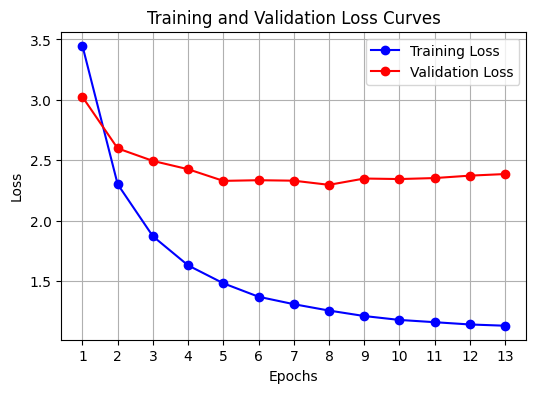

In [24]:
# --- 14. 繪製學習曲線 ---
def plot_loss_curves(train_history, val_history, plot_title):
    epochs = len(train_history)

    # 創建 X 軸 (從 Epoch 1 到 N)
    epoch_range = range(1, epochs + 1)

    # 設置圖表大小
    plt.figure(figsize=(6, 4))

    # 繪製 Training loss 曲線
    plt.plot(epoch_range, train_history, 'b-o', label='Training Loss')

    # 繪製 Validation loss 曲線
    plt.plot(epoch_range, val_history, 'r-o', label='Validation Loss')

    # --- 設置圖表標題與標籤 ---
    plt.title('Training and Validation Loss Curves')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.xticks(epoch_range)
    plt.legend()
    plt.grid(True)

    # 顯示圖表
    plt.show()

plot_loss_curves(train_history, val_history, plot_title="Loss Curves (No Attention)")

## **Inference**

評估(或說推論)的過程與訓練大致相同，但沒有 target，因此我們只是在每一步將 decoder 的預測回饋給自身。每當 decoder 預測一個單字時，我們就把它加到輸出字串中，如果它預測的是 `EOS` token，decoder 輸出就停止。我們還儲存 decoder 的 attention output 以供稍後顯示。

In [25]:
# --- 15. 推論函數 (Inference Function - Greedy Search) ---
def translate_sentence(model, sentence, src_vocab, trg_vocab, device, max_length=50):
    """
    使用 Greedy Search 翻譯一個句子。
    """
    # --- 1. 設定模型為「評估模式」 ---
    model.eval()

    # --- 2. 預處理輸入句子 ---
    normalized_sentence = normalize_string(sentence)
    src_indices = src_vocab.sentence_to_indices(normalized_sentence)
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device) # 轉換為 Tensor，並增加一個 "batch" 維度 (batch_size=1), Shape: [1, src_len]

    # --- 3. 關閉梯度計算 (Inference 時不需要) ---
    with torch.no_grad():
        # --- 4. Encoder ---
        encoder_outputs, hidden = model.encoder(src_tensor) # hidden shape: [num_layers, 1, dec_hidden_size]

    # --- 5. Decoder (Greedy Search) ---
    translated_indices = []
    decoder_input = torch.tensor([[SOS_token]], device=device) # 準備 Decoder 的第一個輸入：<SOS> token, Shape: [1, 1]

    for _ in range(max_length):

        with torch.no_grad():

            #     decoder_output (logits) shape: [1, 1, output_vocab_size]
            #     hidden (new state) shape:   [num_layers, 1, dec_hidden_size]
            decoder_output, hidden, _ = model.decoder(
                decoder_input,
                hidden,
                encoder_outputs # (在無 Attention 時 Decoder 不會用它，但 Seq2Seq 介面會傳入)
            )

        top1 = decoder_output.argmax(2)
        predicted_index = top1.item()

        if predicted_index == EOS_token:
            break

        translated_indices.append(predicted_index)
        decoder_input = top1

    # --- 6. 後處理：將索引轉回單詞 ---
    translated_words_list = [trg_vocab.index2word[idx] for idx in translated_indices]
    translated_words_str = " ".join(translated_words_list)

    # For compatibility with functions expecting 4 return values (like evaluate_bleu)
    # For the non-attention model, src_tokens and attention_matrix are not strictly meaningful
    src_tokens_list = ['<SOS>'] + normalized_sentence.split(' ') + ['<EOS>']
    # Create a dummy attention matrix if no attention is used
    dummy_attention_matrix = torch.zeros(len(translated_words_list), len(src_tokens_list))

    return translated_words_str, src_tokens_list, translated_words_list, dummy_attention_matrix

In [26]:
# 從驗證集的索引中隨機抽取 5 個
validation_indices = val_dataset.indices
random_indices = random.sample(validation_indices, 5)

for i, idx in enumerate(random_indices):
    french_sent, english_sent = val_dataset.dataset.pairs[idx]
    seq2seq_model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
    translation = translate_sentence(seq2seq_model, french_sent, french_vocab, english_vocab, DEVICE )
    print(f"Sample {i+1}:")
    print(f"  Source (French):     {french_sent}")
    print(f"  Reference (English): {english_sent}") # 印出真實的英文句子
    print(f"  Translated (English):{translation}")
    print("-" * 20)

Sample 1:
  Source (French):     tom veut il que je dise quelque chose ?
  Reference (English): does tom want me to say something ?
  Translated (English):('does tom want me to do something ?', ['<SOS>', 'tom', 'veut', 'il', 'que', 'je', 'dise', 'quelque', 'chose', '?', '<EOS>'], ['does', 'tom', 'want', 'me', 'to', 'do', 'something', '?'], tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]))
--------------------
Sample 2:
  Source (French):     je suis amoureux de toi .
  Reference (English): i m in love with you .
  Translated (English):('i m falling with you .', ['<SOS>', 'je', 'suis', 'amoureux', 'de', 'toi',

### **Attention Decoder**

在沒有 attention 機制的 encoder-decoder 架構中 decoder 一開始會採用 encoder 對整串 input sequence 編碼所產生的 context vector，但是這個作法有以下幾個缺點:

- **固定長度的 context 向量成為效能瓶頸:**
由於 encoder 需要將所有資訊壓縮到一個固定長度的向量中，因此在處理長句時，尤其當這些句子比訓練語料庫中的句子更長時，encoder-decoder 的基本架構效能會降低
- **需要完美地將長句編碼成固定長度的向量:**
如此的模型需要完全依靠 encoder 將輸入句子資訊完美地編碼進固定長度的 context vector 中，這使得 encoder 需要承擔較難的任務目標，在長句翻譯的情境下合理地模型效能會變差

## **Attention Mechanism**
Attention 機制的加入讓 decoder 在每一次解碼的時間步驟上可以參考 encoder 每一個時間點的 hidden state 形成動態調整的 context vector $c_t$，$c_t$ 在該解碼的時間點同時也送進 decoder network 中給其進行參照:

<img src="https://hackmd.io/_uploads/HJT2fmdoJx.png" width="70%">


$\text{For } j = 1, \dots, T:$

\begin{align*}
e_{t,j} &= \text{align}(s_{t-1}, h_j) \\
\alpha_{t,j} &= \frac{\exp(e_{t,j})}{\sum_{j=1}^{T} \exp(e_{t,j})} \\
c_t &= \sum_{j=1}^{T} \alpha_{t,j} h_j \\
p(y_t \mid y_1, \dots, y_{t-1}, \mathbf{x}) &= g(s_{t-1}, y_{t-1}, c_t)
\end{align*}

1. 在上面的過程中 decoder 的 hidden state $s_{t-1}$ (**query**) 會去訪問 encoder 的每個 hidden state $h_j$ (**key**) 透過 $align$ 函數進行計算，計算得到的 $e_{t,j}$ 為一個純量，可視為 $s_{t-1}$ 與 $h_j$ 比對後取得的一個分數 **score**, 其代表著 $h_j$ 對於 $s_{t-1}$ 在決定下一個狀態 $s_t$ 與 $y_t$ 的重要性。

2. 在計算出個別的 **score** $e_{t,j} \text{ for } j=1, \dots , T$ 後，對所有的 $e_{t,j}$ 取 *softmax* 得到 **attention weights** $\alpha_{t,1}, \dots,\alpha_{t,T} $, 這些 $\alpha_{t,j}$ 的值會在 0~1 之間且總如為 1。

3. 在計算出 **attention weights:** $\alpha_{t,1}, \dots,\alpha_{t,T}$ 後，將這些 weights 與 encoder 的 hidden states: $h_1, \dots, h_T$ (**values**) 做加權和，產生動態的 context vector $c_t$。

4. 最後，$c_t$ 也被送進 decoder 中在時間點是 t 的時刻，作為 decoder 在該次時間的參照$p(y_t \mid y_1, \dots, y_{t-1}, \mathbf{x}) = g(s_{t-1}, y_{t-1}, c_t)$。


In [27]:
class BahdanauAttention(nn.Module):
    def __init__(self, encoder_hidden_size, decoder_hidden_size, attention_dim):
        super().__init__()
        self.Wa = nn.Linear(decoder_hidden_size, attention_dim) # W_a: 將 Decoder 隱藏狀態 (query) 投影到 attention_dim
        self.Ua = nn.Linear(encoder_hidden_size, attention_dim) # U_a: 將 Encoder 輸出 (keys) 投影到 attention_dim
        self.Va = nn.Linear(attention_dim, 1) # V_a: 將 attention_dim 投影到 1 (得到分數)

    def forward(self, query, keys):
        # query shape: (batch_size, dec_hidden_size)
        # keys shape: (batch_size, src_len, enc_hidden_size)

        # 1. W_a * s_{i-1}
        query_proj = self.Wa(query.unsqueeze(1)) # query_proj: (batch_size, 1, attention_dim)

        # 2. U_a * h_j
        keys_proj = self.Ua(keys) # keys_proj: (batch_size, src_len, attention_dim)

        # 3. 計算能量分數 (energy score)
        #    tanh(...) shape: (batch_size, src_len, attention_dim)
        scores = self.Va(torch.tanh(query_proj + keys_proj)) # (batch_size, src_len, 1)
        scores = scores.squeeze(2) # (batch_size, src_len)

        # 4. 計算 Attention 權重
        attn_weights = F.softmax(scores, dim=1) # (batch_size, src_len)

        # 5. 計算 Context 向量
        #    attn_weights.unsqueeze(1): (batch_size, 1, src_len)
        #    keys (encoder_outputs): (batch_size, src_len, encoder_hidden_size)
        context = torch.bmm(attn_weights.unsqueeze(1), keys)  # context: (batch_size, 1, encoder_hidden_size)

        return context, attn_weights.unsqueeze(1)

In [28]:
class AttnDecoderRNN(nn.Module):
    def __init__(self, output_vocab_size, embedding_dim, encoder_hidden_size,
                 decoder_hidden_size, attention_dim, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(output_vocab_size, embedding_dim, padding_idx=PAD_token)
        self.dropout = nn.Dropout(dropout)

        # 將三個維度參數都傳給 Attention 模組
        self.attention = BahdanauAttention(encoder_hidden_size,
                                           decoder_hidden_size,
                                           attention_dim)

        # GRU 的輸入維度仍然是 embedding_dim + encoder_hidden_size
        # (因為 context vector c_i 的維度 = encoder_hidden_size)
        self.gru = nn.GRU(embedding_dim + encoder_hidden_size,
                          decoder_hidden_size,
                          num_layers=num_layers,
                          batch_first=True)

        self.fc_out = nn.Linear(decoder_hidden_size, output_vocab_size)

        # (儲存其他參數...)
        self.output_vocab_size = output_vocab_size
        self.decoder_hidden_size = decoder_hidden_size
        self.num_layers = num_layers

    def forward(self, decoder_input, decoder_hidden, encoder_outputs):
        # 1. Embedding
        embedded = self.embedding(decoder_input) # (batch_size, 1, embedding_dim)
        embedded = self.dropout(embedded)

        # 2. 計算 Attention
        #    decoder_hidden[-1]: (batch_size, decoder_hidden_size)
        context, attn_weights = self.attention(decoder_hidden[-1], encoder_outputs)
        # context: (batch_size, 1, encoder_hidden_size)
        # attn_weights: (batch_size, 1, src_len)

        # 3. 拼接
        rnn_input = torch.cat((embedded, context), dim=2)
        # rnn_input: (batch_size, 1, embedding_dim + encoder_hidden_size)

        # 4. GRU
        gru_output, hidden = self.gru(rnn_input, decoder_hidden)
        # gru_output: (batch_size, 1, decoder_hidden_size)
        # hidden: (num_layers, batch_size, decoder_hidden_size)

        # 5. 輸出
        output = self.fc_out(gru_output) # (batch_size, 1, output_vocab_size)

        return output, hidden, attn_weights

In [29]:
# 模型參數設定(加入 Attention)
INPUT_VOCAB_SIZE = french_vocab.n_words
OUTPUT_VOCAB_SIZE = english_vocab.n_words
EMBEDDING_DIM = 256
ENCODER_HIDDEN_SIZE = 512
DECODER_HIDDEN_SIZE = 512
NUM_LAYERS = 2
DROPOUT = 0.3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ATTENTION_DIM = 256 # Bahdanau attention 內部的維度

# 創建 Encoder 和 Decoder 實例
encoder_attn = EncoderRNN(INPUT_VOCAB_SIZE, EMBEDDING_DIM, ENCODER_HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
decoder_attn = AttnDecoderRNN(OUTPUT_VOCAB_SIZE, EMBEDDING_DIM, ENCODER_HIDDEN_SIZE, DECODER_HIDDEN_SIZE, ATTENTION_DIM, NUM_LAYERS, DROPOUT).to(DEVICE)

# 創建 Seq2Seq 模型實例
seq2seq_model_attn = Seq2Seq(encoder_attn, decoder_attn, DEVICE).to(DEVICE)

# 印出模型結構
print("Seq2Seq Model with Attention")
print(seq2seq_model_attn)

Seq2Seq Model with Attention
Seq2Seq(
  (encoder): EncoderRNN(
    (embedding): Embedding(21335, 256, padding_idx=0)
    (gru): GRU(256, 512, num_layers=2, batch_first=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): AttnDecoderRNN(
    (embedding): Embedding(13044, 256, padding_idx=0)
    (dropout): Dropout(p=0.3, inplace=False)
    (attention): BahdanauAttention(
      (Wa): Linear(in_features=512, out_features=256, bias=True)
      (Ua): Linear(in_features=512, out_features=256, bias=True)
      (Va): Linear(in_features=256, out_features=1, bias=True)
    )
    (gru): GRU(768, 512, num_layers=2, batch_first=True)
    (fc_out): Linear(in_features=512, out_features=13044, bias=True)
  )
)


In [30]:
# 訓練超參數
N_EPOCHS = 20
BATCH_SIZE = 64
LEARNING_RATE = 0.001
CLIP = 1.0
TEACHER_FORCING_RATIO = 0.5
EARLY_STOP_PATIENCE = 5
SAVE_PATH = 'best_seq2seq_model_WITH_attn.pt' # 儲存新模型

# 呼叫主訓練函數

train_history_attn, val_history_attn = train_model(
    model=seq2seq_model_attn,  # 傳入新的 attention-based model
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    collate_fn=collate_fn,
    device=DEVICE,
    n_epochs=N_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    teacher_forcing_ratio=TEACHER_FORCING_RATIO,
    clip=CLIP,
    save_path=SAVE_PATH, # 儲存到新的路徑
    early_stopping_patience=EARLY_STOP_PATIENCE
)

print("\n--- Attention Model Training Finished ---")
print(f"Best model saved to: {SAVE_PATH}")


--- Starting Training---
Total Epochs: 20
Batch Size: 64
Device: cuda
Saving best model to: best_seq2seq_model_WITH_attn.pt
Early Stopping Patience: 5
----------------------------------------


Training:   0%|          | 0/1911 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/213 [00:00<?, ?it/s]


Epoch 1/20
	Train Loss: 3.7324
	Val. Loss: 3.1903
	Validation loss improved (3.1903). Saving model to best_seq2seq_model_WITH_attn.pt


Training:   0%|          | 0/1911 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/213 [00:00<?, ?it/s]


Epoch 12/20
	Train Loss: 1.0640
	Val. Loss: 2.3139
	Validation loss did not improve. Patience: 4/5


Training:   0%|          | 0/1911 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/213 [00:00<?, ?it/s]


Epoch 13/20
	Train Loss: 1.0500
	Val. Loss: 2.3233
	Validation loss did not improve. Patience: 5/5

Early stopping triggered after epoch 13!
--- Training finished early after 13 epochs ---
Best Validation Loss achieved: 2.2579

--- Attention Model Training Finished ---
Best model saved to: best_seq2seq_model_WITH_attn.pt


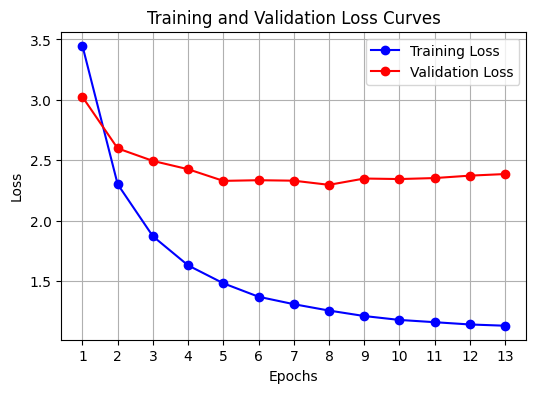

In [31]:
plot_loss_curves(train_history, val_history, plot_title="Loss Curves (Attention)")

In [32]:
def translate_sentence_attn(model, sentence, src_vocab, trg_vocab, device, max_length=50):
    """
    使用 Greedy Search 翻譯一個句子。
    """
    # --- 1. 設定模型為「評估模式」 ---
    model.eval()

    # --- 2. 預處理輸入句子 ---
    normalized_sentence = normalize_string(sentence)
    # *** 需要手動加入 <SOS> 和 <EOS> 標記，以匹配 attention 矩陣的維度 ***
    src_tokens = ['<SOS>'] + normalized_sentence.split(' ') + ['<EOS>']

    src_indices = src_vocab.sentence_to_indices(normalized_sentence)
    src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device) # 轉換為 Tensor，並增加一個 "batch" 維度 (batch_size=1), Shape: [1, src_len]

    # --- 3. 關閉梯度計算 (Inference 時不需要) ---
    with torch.no_grad():
        # --- 4. Encoder ---
        encoder_outputs, hidden = model.encoder(src_tensor) # hidden shape: [num_layers, 1, dec_hidden_size]

    # --- 5. Decoder (Greedy Search) ---
    translated_indices = []
    all_attentions = [] # *** 用於儲存 attention 的權重 ***
    decoder_input = torch.tensor([[SOS_token]], device=device) # 準備 Decoder 的第一個輸入：<SOS> token, Shape: [1, 1]

    for _ in range(max_length):

        with torch.no_grad():

            # *** attn_weights shape: (batch_size, 1, src_len) -> (1, 1, src_len)***
            decoder_output, hidden, attn_weights = model.decoder(
                decoder_input,
                hidden,
                encoder_outputs
            )
            all_attentions.append(attn_weights.squeeze(1).cpu())

        top1 = decoder_output.argmax(2)
        predicted_index = top1.item()

        if predicted_index == EOS_token:
            break

        translated_indices.append(predicted_index)
        decoder_input = top1

    # --- 6. 後處理：將索引轉回單詞 ---
    translated_words = [trg_vocab.index2word[idx] for idx in translated_indices]
    # *** 儲存 attention 權重 ***
    # squeeze(1) 移除中間的 '1' 維度，得到 (1, src_len)
    # 並 .cpu() 將其移回 CPU 以便後續處理
    attention_matrix = torch.cat(all_attentions, dim=0)

    return " ".join(translated_words), src_tokens, translated_words, attention_matrix

In [33]:
# 從驗證集的索引中隨機抽取 5 個
validation_indices = val_dataset.indices
random_indices = random.sample(validation_indices, 5)

for i, idx in enumerate(random_indices):
    french_sent, english_sent = val_dataset.dataset.pairs[idx]
    seq2seq_model_attn.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
    translation, src_tokens, translated_words, attention_matrix = translate_sentence_attn(seq2seq_model_attn, french_sent, french_vocab, english_vocab, DEVICE )
    print(f"Sample {i+1}:")
    print(f"  Source (French):     {french_sent}")
    print(f"  Reference (English): {english_sent}") # 印出真實的英文句子
    print(f"  Translated (English):{translation}")
    print("-" * 20)

Sample 1:
  Source (French):     le piano a un bon timbre .
  Reference (English): the piano has a good tone .
  Translated (English):the driver has a good at .
--------------------
Sample 2:
  Source (French):     tom se comporte bizarrement .
  Reference (English): tom has been behaving oddly .
  Translated (English):tom jackson himself .
--------------------
Sample 3:
  Source (French):     tu es dingue .
  Reference (English): you re insane .
  Translated (English):you re crazy .
--------------------
Sample 4:
  Source (French):     quelle est la marque ?
  Reference (English): what s the score ?
  Translated (English):what s the population ?
--------------------
Sample 5:
  Source (French):     venez nous rejoindre !
  Reference (English): come join us .
  Translated (English):come and sit down .
--------------------


In [34]:
import matplotlib.ticker as ticker

def plot_attention(source_words, translated_words, attention_matrix):
    """
    繪製 Attention 權重矩陣 (熱力圖)。
    """

    # 設置圖表大小
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot(111)

    # 繪製熱力圖
    # cax = ax.matshow(attention_matrix, cmap='bone') # 'bone' 是黑白主題
    cax = ax.matshow(attention_matrix.numpy(), cmap='gray') # 使用 .numpy()

    # 添加顏色條
    fig.colorbar(cax)

    # --- 設置 X 軸 (來源單詞) ---
    # 設置刻度位置在每個單詞的中間
    ax.set_xticks(range(len(source_words)))
    # 設置 X 軸的標籤 (單詞)
    ax.set_xticklabels(source_words, rotation=90)
    # 將 X 軸刻度標籤移到圖表頂部
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_ticks_position('top')


    # --- 設置 Y 軸 (目標單詞) ---
    # 設置刻度位置
    ax.set_yticks(range(len(translated_words)))
    # 設置 Y 軸的標籤 (單詞)
    ax.set_yticklabels(translated_words)
    # Y 軸使用正常的 1, 2, 3... 刻度
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    print("Displaying Attention Plot...")
    plt.show()

In [35]:
def translate_and_visualize(model_attn_loaded, sentence):
    """一個輔助函數，用來結合翻譯和繪圖"""
    print("-" * 30)
    print(f"Source (FR): {sentence}")

    # 1. 呼叫更新後的翻譯函數
    translation, src_tokens, trg_tokens, attention_matrix = translate_sentence_attn(
        model_attn_loaded,
        sentence,
        french_vocab,
        english_vocab,
        DEVICE
    )

    print(f"Greedy (EN): {translation}")

    # 2. 呼叫繪圖函數
    plot_attention(src_tokens, trg_tokens, attention_matrix)
    print("-" * 30)

------------------------------
Source (FR): elle sait quoi faire maintenant .
Greedy (EN): she knows what to do now now now now .
Displaying Attention Plot...


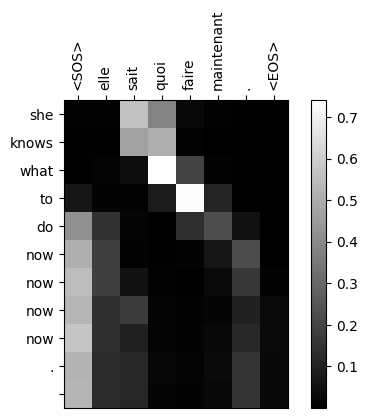

------------------------------
------------------------------
Source (FR): c est une voiture de fonction .
Greedy (EN): that s a car of .
Displaying Attention Plot...


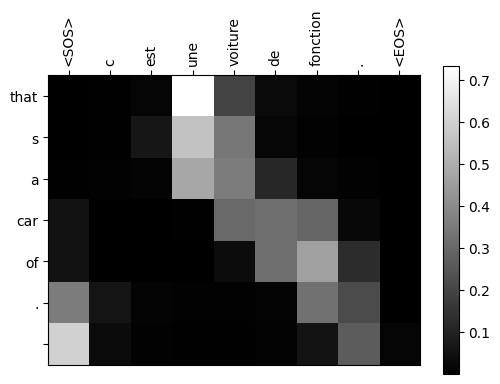

------------------------------
------------------------------
Source (FR): on dirait qu il est en train de gagner .
Greedy (EN): it sounds like it is crying .
Displaying Attention Plot...


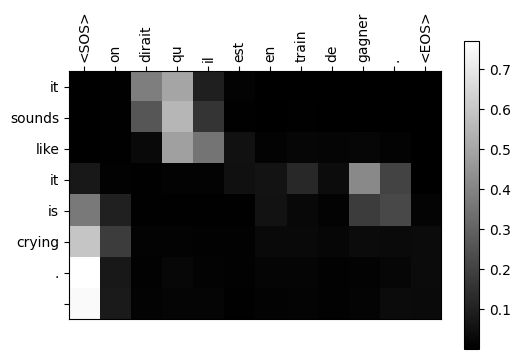

------------------------------
------------------------------
Source (FR): on reconnait un arbre a son fruit .
Greedy (EN): one tree was built fruit .
Displaying Attention Plot...


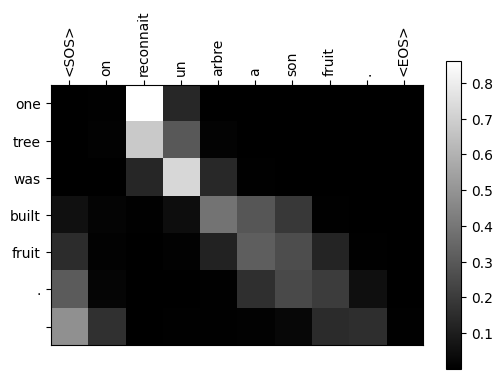

------------------------------
------------------------------
Source (FR): aucun probleme .
Greedy (EN): no problem .
Displaying Attention Plot...


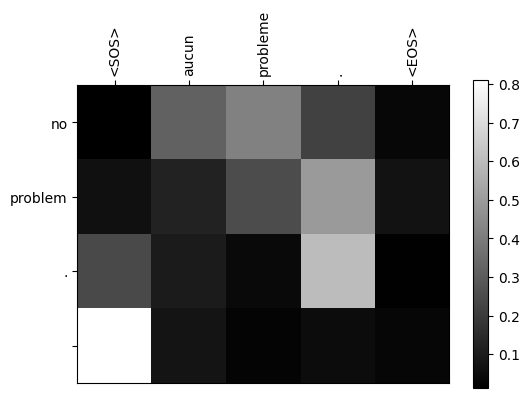

------------------------------


In [36]:
validation_indices = val_dataset.indices
random_indices = random.sample(validation_indices, 5)
seq2seq_model_attn.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

for i, idx in enumerate(random_indices):
    french_sent, english_sent = val_dataset.dataset.pairs[idx]
    translate_and_visualize(seq2seq_model_attn, french_sent)

## **Evaluation**

In [37]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_bleu(model, dataset, src_vocab, trg_vocab, device, translate_fn, max_length=50):
    references = [] # 標準答案 (Ground Truth)
    candidates = [] # 模型預測 (Model Prediction)

    # NLTK 需要一個平滑函數來處理 n-gram 未命中的情況
    chen_smoothing = SmoothingFunction().method4

    model.eval()

    # 由於 dataset 可能是 random_split 的 Subset，其 indices 指向原始 dataset
    # 我們只評估前 100 筆，如果想評估全部，請調整或移除此限制
    dataset_subset = dataset.indices

    total_bleu_score = 0.0

    with torch.no_grad():
        for original_data_idx in tqdm(dataset_subset, desc="Calculating BLEU (NLTK)"):

            src_sentence, trg_sentence = dataset.dataset.pairs[original_data_idx]

            # 1. 產生翻譯，使用傳入的 translate_fn
            translation, _, _, _ = translate_fn(
                model,
                src_sentence,
                src_vocab,
                trg_vocab,
                device,
                max_length
            )

            # 2. 準備 NLTK 所需的格式 (list of strings)
            candidate_tokens = translation.split(' ')

            # reference 要是一個 "list of lists" (因為可能有 N 個參考翻譯)
            reference_tokens = [trg_sentence.split(' ')]

            # 3. 計算單一句子分數
            sentence_score = sentence_bleu(
                reference_tokens,
                candidate_tokens,
                smoothing_function=chen_smoothing
            )

            total_bleu_score += sentence_score

    # 4. 計算最終的 BLEU 分數 (取平均)
    final_bleu = total_bleu_score / len(dataset_subset)

    return final_bleu * 100 # (報告 0-100 的分數)

In [38]:
bleu_score_attn = evaluate_bleu(
    seq2seq_model_attn,
    val_dataset,
    french_vocab,
    english_vocab,
    DEVICE,
    translate_sentence_attn
)

print(f"BLEU score for Seq2Seq (with attention): {bleu_score_attn:.2f}")

Calculating BLEU (NLTK):   0%|          | 0/13585 [00:00<?, ?it/s]

BLEU score for Seq2Seq (with attention): 37.57
